# Which attention head is doing the work?

This is the trained 4-layer, 4-head GPT from the progression (`progression/04_full_gpt.ipynb`, 30k steps, val 1.65), opened up. The question I'm after is narrow: when this model predicts the next character, *which of its 16 attention heads actually carries the prediction, and how do I know?*

I run six analyses, and the structure matters: two only *look* at the network (attention patterns, the residual stream), and the rest *intervene* on it. The reason I don't stop at the attention maps is the first thing the interventions turn up — the model has **two** heads that look like previous-token heads, and only one of them does anything. Pulling those two apart is the whole point.

| # | Analysis | Type | What it answers |
|---|----------|------|------------------|
| 1 | Attention patterns | correlational | what does each head attend to? |
| 2 | Head ablation | causal (coarse) | how much does each head matter? |
| 3 | Redundancy (pairwise ablation) | causal | *why* doesn't the second prev-token head matter? |
| 4 | Residual patching | causal | where does the information flow? |
| 5 | Head patching | causal (isolating) | is it really *that head*? |
| 6 | Logit lens + seeds | descriptive | how does the prediction form, and does this replicate? |

## Setup

Load the committed checkpoint and a fixed held-out set. Everything below draws from fixed-seed generators, so the numbers reproduce across runs and machines.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np, torch, matplotlib.pyplot as plt
from models import GPT
from gpt import make_dataset
from gpt.analysis import (eval_batches, attention_summary, classify_head,
                          head_ablation, redundancy_test, activation_patching,
                          head_patching, residual_profile)

model = GPT.from_pretrained(os.path.abspath(os.path.join(os.getcwd(), '..', 'assets', 'gpt.pth')))
ds = make_dataset(); T = model.config.block_size
batches = eval_batches(ds, T, 32, 16)   # 16 batches x 32 = 512 held-out sequences
print(f'{model.num_params()/1e6:.6f}M params | {model.config.n_layer}x{model.config.n_head} heads | block {T}')

0.209729M params | 4x4 heads | block 32


## 1. What each head attends to (correlational)

I average each head's attention over 512 validation sequences and summarize it with five per-query-position statistics: weight on the previous token (`prev`), on the first position (`first`, a sink), on itself (`self`), the mean attended distance (`dist`), and the entropy (how spread out it is). A head with `prev≈1` and near-zero entropy is a clean previous-token head. These are tendencies, not functions — that's what the interventions are for.

In [2]:
mean_maps, stats = attention_summary(model, batches)
print(f"{'L.H':>4} {'prev':>6} {'first':>6} {'self':>6} {'dist':>6} {'entropy':>8}  label")
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        s = stats[(l, h)]
        print(f"{l}.{h:>2} {s['prev']:6.3f} {s['first']:6.3f} {s['self']:6.3f} "
              f"{s['dist']:6.2f} {s['entropy']:8.3f}  {classify_head(s)}")

 L.H   prev  first   self   dist  entropy  label
0. 0  0.095  0.103  0.099   7.93    2.622  diffuse / long-range
0. 1  0.132  0.093  0.082   6.63    2.502  diffuse / long-range
0. 2  0.104  0.101  0.094   7.74    2.617  diffuse / long-range
0. 3  0.819  0.042  0.029   1.73    0.793  previous-token
1. 0  0.396  0.046  0.147   1.65    0.984  previous-token
1. 1  0.980  0.034  0.003   1.07    0.089  previous-token
1. 2  0.419  0.044  0.141   1.73    1.017  previous-token
1. 3  0.356  0.041  0.209   1.57    0.989  previous-token
2. 0  0.304  0.038  0.225   1.93    0.995  local (short-range)
2. 1  0.307  0.048  0.211   2.41    1.126  diffuse / long-range
2. 2  0.439  0.041  0.216   1.69    0.761  previous-token
2. 3  0.373  0.043  0.216   1.60    0.621  previous-token
3. 0  0.282  0.034  0.339   1.81    0.848  local (short-range)
3. 1  0.322  0.043  0.283   2.01    0.955  diffuse / long-range
3. 2  0.228  0.063  0.193   3.64    1.327  diffuse / long-range
3. 3  0.297  0.043  0.254   2.23   

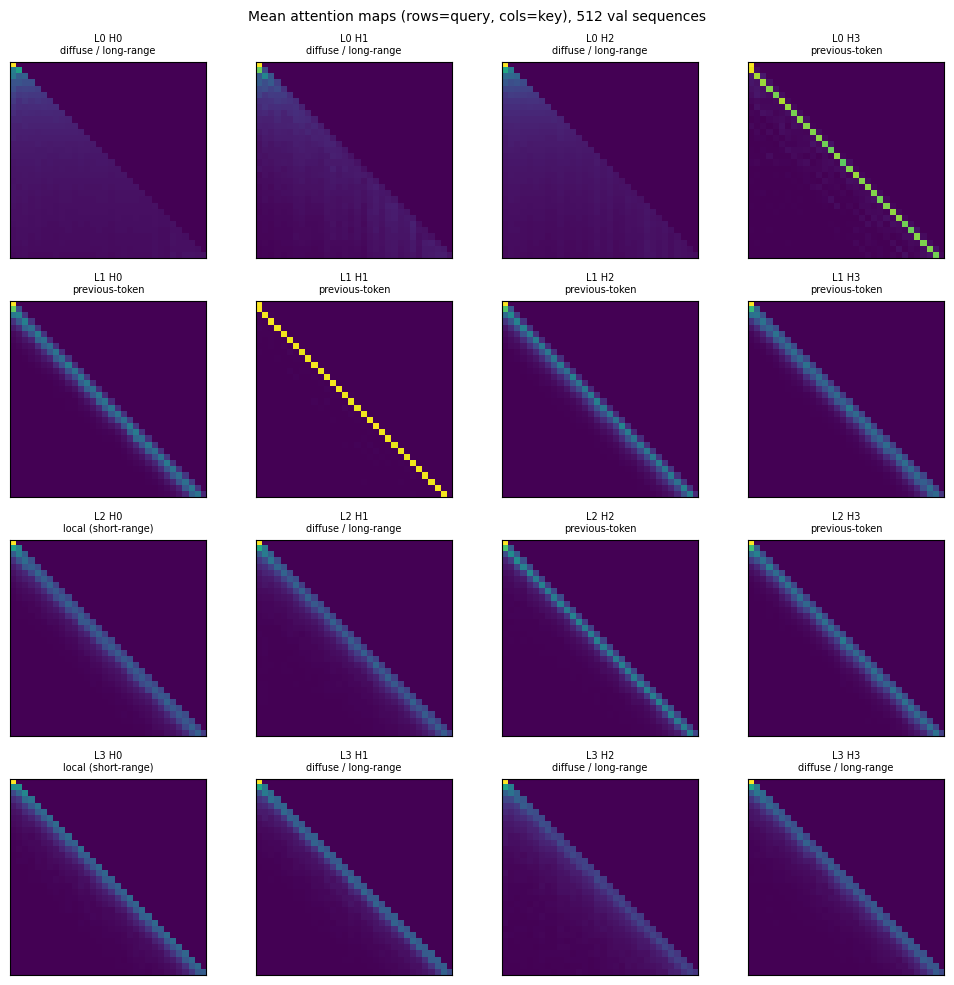

In [3]:
fig, ax = plt.subplots(model.config.n_layer, model.config.n_head, figsize=(10, 10))
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        ax[l,h].imshow(mean_maps[l, h].numpy(), cmap='viridis')
        ax[l,h].set_title(f'L{l} H{h}\n{classify_head(stats[(l,h)])}', fontsize=7)
        ax[l,h].set_xticks([]); ax[l,h].set_yticks([])
fig.suptitle('Mean attention maps (rows=query, cols=key), 512 val sequences', fontsize=10)
fig.tight_layout(); fig.savefig('../assets/attention_grid.png', dpi=120, bbox_inches='tight'); plt.show()

What I see: layer 0 is mostly diffuse, layer 1 leans hard on the previous token, and layers 2–3 do shorter-range, more self-weighted mixing. Two heads stand out as sharp previous-token heads — **L1 H1** (prev ≈ 0.98, entropy ≈ 0.09, a single bright sub-diagonal) and **L0 H3** (prev ≈ 0.82). On the maps they look like the same kind of head. The next sections show they are nothing alike where it counts.

## 2. How much each head matters (coarse causal)

I zero one head's output at a time and remeasure validation loss. The error bar is the standard error of the *paired* per-batch difference (ablated minus intact on the same batch), which cancels the batch-to-batch noise in the base loss.

In [4]:
base, delta, dsem = head_ablation(model, ds, batches)
print(f'base val loss: {base:.4f}\n')
for l in range(model.config.n_layer):
    print(' '.join(f'L{l}H{h}:{delta[l,h]:+.3f}±{dsem[l,h]:.3f}' for h in range(model.config.n_head)))
order = sorted(((delta[l,h], l, h) for l in range(model.config.n_layer)
                for h in range(model.config.n_head)), reverse=True)
print('\ntop-5:', [(f'L{l}H{h}', round(d,4)) for d,l,h in order[:5]])

base val loss: 1.6668

L0H0:+0.021±0.002 L0H1:-0.000±0.000 L0H2:+0.016±0.002 L0H3:+0.040±0.002
L1H0:+0.037±0.003 L1H1:+0.885±0.017 L1H2:+0.049±0.004 L1H3:+0.051±0.004
L2H0:+0.059±0.003 L2H1:+0.058±0.003 L2H2:+0.093±0.005 L2H3:+0.126±0.005
L3H0:+0.048±0.003 L3H1:+0.069±0.003 L3H2:+0.028±0.002 L3H3:+0.048±0.003

top-5: [('L1H1', np.float64(0.8853)), ('L2H3', np.float64(0.1259)), ('L2H2', np.float64(0.0925)), ('L3H1', np.float64(0.0689)), ('L2H0', np.float64(0.0594))]


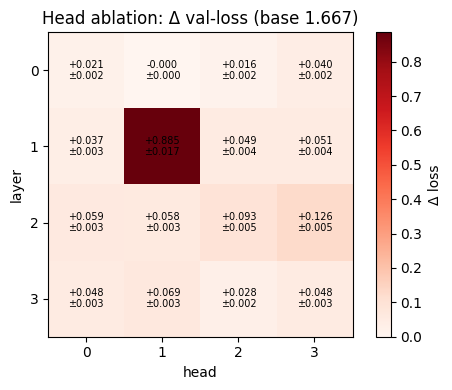

In [5]:
fig, ax = plt.subplots(figsize=(5.2,4)); im = ax.imshow(delta, cmap='Reds')
ax.set_xlabel('head'); ax.set_ylabel('layer')
ax.set_xticks(range(model.config.n_head)); ax.set_yticks(range(model.config.n_layer))
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        ax.text(h, l, f'{delta[l,h]:+.3f}\n±{dsem[l,h]:.3f}', ha='center', va='center', fontsize=7)
ax.set_title(f'Head ablation: Δ val-loss (base {base:.3f})'); fig.colorbar(im, ax=ax, label='Δ loss')
fig.tight_layout(); fig.savefig('../assets/head_ablation.png', dpi=120, bbox_inches='tight'); plt.show()

Here's the split. **L1 H1 costs ≈ 0.89 ± 0.02 nats to ablate** — seven times the next head (L2 H3 at ≈ 0.13) and far outside the error bar. **L0 H3, the other sharp previous-token head, costs ≈ 0.04 ± 0.00.** Two heads that are nearly indistinguishable on the attention maps are an order of magnitude apart in how much the model needs them. So the attention pattern told me *where a head looks*, not *whether it's load-bearing* — and I'd have been wrong to call L0 H3 important on the maps alone. The obvious next question: why doesn't it matter?

## 3. Why the second prev-token head doesn't matter (redundancy)

My guess was redundancy: L0 H3 computes a previous-token signal, but L1 H1 computes a stronger one a layer later, so removing L0 H3 alone changes little. That's testable directly — ablate L0 H3 on its own, then ablate it again with L1 H1 *already* gone, and compare the marginal cost. If it's redundancy, L0 H3 should suddenly matter once its backup is removed.

In [6]:
r = redundancy_test(model, batches, a=(0,3), b=(1,1))
print(f"base                         {r['base']:.4f}")
print(f"ablate L0H3                  {r['ablate_a']:.4f}   (marginal +{r['marg_a_alone']:.4f})")
print(f"ablate L1H1                  {r['ablate_b']:.4f}")
print(f"ablate BOTH                  {r['ablate_both']:.4f}")
print(f"=> marginal cost of L0H3 alone:          +{r['marg_a_alone']:.4f}")
print(f"=> marginal cost of L0H3 given L1H1 gone: +{r['marg_a_given_b']:.4f}")

base                         1.6668
ablate L0H3                  1.7070   (marginal +0.0401)
ablate L1H1                  2.5521
ablate BOTH                  2.7803
=> marginal cost of L0H3 alone:          +0.0401
=> marginal cost of L0H3 given L1H1 gone: +0.2282


That settles it. Ablating L0 H3 on its own costs ≈ 0.04, but ablating it once L1 H1 is already gone costs ≈ 0.23 — almost six times as much. L0 H3 isn't dead weight; it's a redundant previous-token head whose contribution is masked by the stronger L1 H1. The interventions earn their keep right here: nothing in the attention maps, and nothing in single-head ablation, would have told me that the cheap-to-remove head is actually doing the same job as the expensive one.

## 4. Where the information flows (residual patching)

Ablation says L1 H1 matters; it doesn't say what path the information takes. For that I corrupt a token and trace where restoring the clean activation brings the prediction back.

For each example: run a clean context, record the top next-character prediction, and cache the residual stream. Corrupt the token two positions from the end and rerun — the prediction shifts. Then patch the clean residual back in at each (layer, position), one site at a time, and measure recovery:

$$\text{recovery} = \frac{m_\text{patched} - m_\text{corrupt}}{m_\text{clean} - m_\text{corrupt}}$$

The metric `m` is a contrastive logit difference (clean top token vs. the token the corruption promotes), which is less sensitive to overall distribution shifts than a single token's probability. I only keep examples where the corruption actually *flips* the top-1 prediction — a clean, reportable selection rather than a magic threshold. Corrupting near but not *at* the prediction site forces the information to travel, so the map shows which layer moves it. The clean-patch-is-identity invariant this leans on is a unit test (`tests/test_smoke.py`).

In [7]:
rec, rsem, used, cpos = activation_patching(model, ds, n_examples=256)
print(f'corrupt pos {cpos}, predict at {T-1}, {used} examples (those where the prediction flipped)\n')
labels = ['emb'] + [f'blk{k}' for k in range(model.config.n_layer)]
for k in range(rec.shape[0]):
    print(f'  resid[{k}] ({labels[k]:>4}): ' + '  '.join(f'p{p}:{rec[k,p]:.2f}±{rsem[k,p]:.2f}' for p in range(cpos, T)))

corrupt pos 30, predict at 31, 189 examples (those where the prediction flipped)

  resid[0] ( emb): p30:1.00±0.00  p31:0.00±0.00
  resid[1] (blk0): p30:0.97±0.01  p31:0.07±0.02
  resid[2] (blk1): p30:0.24±0.04  p31:0.74±0.03
  resid[3] (blk2): p30:0.07±0.02  p31:0.91±0.01
  resid[4] (blk3): p30:0.00±0.00  p31:1.00±0.00


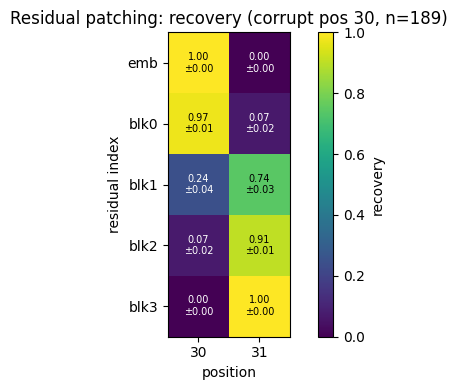

In [8]:
sub, ssem = rec[:,cpos:], rsem[:,cpos:]
fig, ax = plt.subplots(figsize=(6,4)); im = ax.imshow(sub, cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('position'); ax.set_ylabel('residual index')
ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(range(cpos, T))
ax.set_yticks(range(rec.shape[0])); ax.set_yticklabels(labels)
for k in range(rec.shape[0]):
    for j in range(sub.shape[1]):
        ax.text(j,k,f'{sub[k,j]:.2f}\n±{ssem[k,j]:.2f}', ha='center', va='center',
                color='white' if sub[k,j]<0.6 else 'black', fontsize=7)
ax.set_title(f'Residual patching: recovery (corrupt pos {cpos}, n={used})')
fig.colorbar(im, ax=ax, label='recovery'); fig.tight_layout()
fig.savefig('../assets/activation_patching.png', dpi=120, bbox_inches='tight'); plt.show()

A clean handoff, localized to one layer. Through the embedding and block 0 the corrupted information sits on its own position; **after block 1 it has moved to the prediction position** (recovery jumps from ≈ 0.24 at the corrupted slot to ≈ 0.74 at the prediction slot), and blocks 2–3 carry it the rest of the way. Block 1 is where L1 H1 lives — but I want to be careful here: this patches the residual *sum* at a position, so it shows block 1 does the move, not that L1 H1 specifically does it. The next analysis closes that gap.

## 5. Is it really *that head*? (head patching)

Residual patching localizes the move to block 1, but block 1 has four heads (and an FFN, and the residual carry). To pin it on L1 H1, I patch at the level of a single head: same clean/corrupt setup, but instead of restoring the residual at a position, I splice **one head's clean output** into the corrupted run and leave everything else corrupted. Whatever prediction comes back is attributable to that head alone. The head-level identity invariant (splicing a head's own clean output is a no-op) is also a unit test.

In [9]:
hrec, hsem, hused, _ = head_patching(model, ds, n_examples=256)
order = sorted(((hrec[l,h],l,h) for l in range(model.config.n_layer)
                for h in range(model.config.n_head)), reverse=True)
print(f'{hused} examples\ntop heads by single-head recovery:')
for r,l,h in order[:5]:
    print(f'  L{l}H{h}: {r:.3f} ± {hsem[l,h]:.3f}')

189 examples
top heads by single-head recovery:
  L1H1: 0.510 ± 0.029
  L2H3: 0.110 ± 0.023
  L1H2: 0.102 ± 0.025
  L2H2: 0.089 ± 0.015
  L3H1: 0.087 ± 0.025


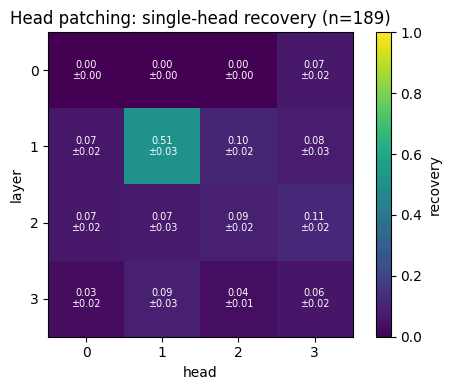

In [10]:
fig, ax = plt.subplots(figsize=(5.2,4)); im = ax.imshow(hrec, cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('head'); ax.set_ylabel('layer')
ax.set_xticks(range(model.config.n_head)); ax.set_yticks(range(model.config.n_layer))
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        ax.text(h,l,f'{hrec[l,h]:.2f}\n±{hsem[l,h]:.2f}', ha='center', va='center',
                color='white' if hrec[l,h]<0.6 else 'black', fontsize=7)
ax.set_title(f'Head patching: single-head recovery (n={hused})'); fig.colorbar(im, ax=ax, label='recovery')
fig.tight_layout(); fig.savefig('../assets/head_patching.png', dpi=120, bbox_inches='tight'); plt.show()

This is the result I was after. **Splicing L1 H1's clean output back in, on its own, recovers ≈ 0.51 ± 0.03 of the prediction** — five times the next head (L2 H3 at ≈ 0.11). One head out of sixteen accounts for roughly half the effect by itself. It isn't 100%, and it shouldn't be: the previous-token signal also flows partly through other heads and the residual carry, which is exactly why no single head hits 1.0. But the isolation is direct now — I'm no longer inferring L1 H1 from the coincidence of "block 1 matters" and "L1 H1 ablates hardest," I'm routing its clean output into a corrupted run and watching the prediction come back.

## 6. How the prediction forms, and whether this replicates

Two loose ends. First, the residual stream: I read each layer's stream through the final unembedding (the logit lens) to see how sharply the prediction has formed by each depth.

          emb: |resid|=  8.52  logit-lens CE=5.0477  acc=0.0607
   after blk0: |resid|= 10.90  logit-lens CE=4.0952  acc=0.1169
   after blk1: |resid|= 17.79  logit-lens CE=3.1943  acc=0.2080
   after blk2: |resid|= 21.38  logit-lens CE=2.4565  acc=0.3440
   after blk3: |resid|= 45.64  logit-lens CE=1.6668  acc=0.5101


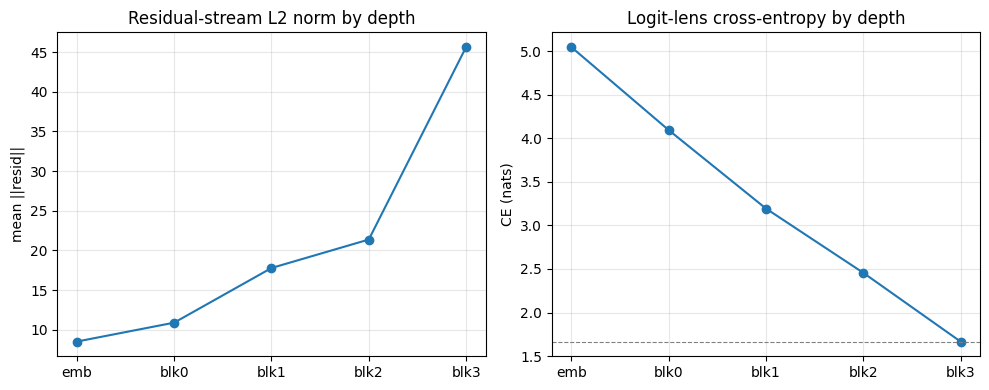

In [11]:
norms, ce, acc = residual_profile(model, batches)
labels = ['emb'] + [f'after blk{k}' for k in range(model.config.n_layer)]
for k in range(len(norms)):
    print(f'  {labels[k]:>11}: |resid|={norms[k]:6.2f}  logit-lens CE={ce[k]:.4f}  acc={acc[k]:.4f}')
ks=list(range(len(norms))); xl=['emb']+[f'blk{k}' for k in range(len(norms)-1)]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10,4))
a1.plot(ks,norms,'o-'); a1.set_title('Residual-stream L2 norm by depth'); a1.set_xticks(ks); a1.set_xticklabels(xl); a1.set_ylabel('mean ||resid||'); a1.grid(alpha=0.3)
a2.plot(ks,ce,'o-'); a2.set_title('Logit-lens cross-entropy by depth'); a2.set_xticks(ks); a2.set_xticklabels(xl); a2.set_ylabel('CE (nats)'); a2.grid(alpha=0.3); a2.axhline(ce[-1],ls='--',c='gray',lw=0.8)
fig.tight_layout(); fig.savefig('../assets/residual_logitlens.png', dpi=120, bbox_inches='tight'); plt.show()

The prediction sharpens monotonically — logit-lens accuracy climbs **0.06 → 0.12 → 0.21 → 0.34 → 0.51** across the four blocks, the final block doing the most, and the final-depth readout equals the model's real loss (a wiring check). The residual norm grows and the embedding-level readout already reaches 6% — a weak unigram prior baked into the static embeddings before any attention runs.

Second, and more important: is "L1 H1" an initialization accident? I retrained the same architecture from four more seeds (at a reduced 3k-step budget — head specialization is unambiguous well before convergence) and recorded, for each, the single most causally important head and its attention pattern.

In [12]:
sr = json.load(open(os.path.abspath(os.path.join(os.getcwd(), '..', 'assets', 'seed_robustness.json'))))
print(f"{'seed':>6} {'top head':>9} {'prev':>6}  {'label':<16} steps")
for d in sr:
    l,h = d['top_head']
    print(f"{d['seed']:>6}   L{l}H{h:<5} {d['top_prev']:>6.3f}  {d['top_label']:<16} {d['steps']}")
print('\nmost-important head is a sharp previous-token head in layer 0/1 for all seeds:',
      all(d['top_is_prev_token_L01'] for d in sr))

  seed  top head   prev  label            steps
     0   L0H1      0.973  previous-token   3000
     1   L0H3      0.967  previous-token   3000
     2   L0H0      0.896  previous-token   3000
     3   L0H1      0.943  previous-token   3000
  1337   L1H1      0.941  previous-token   3000

most-important head is a sharp previous-token head in layer 0/1 for all seeds: True


This is the honest version of the headline. Across five seeds, the most causally important head is **always** a sharp previous-token head (prev 0.90–0.97) sitting in layer 0 or 1 — but *which* head it lands in moves around (L1 H1 here, L0 H1 / L0 H3 / L0 H0 elsewhere). So the mechanism replicates; the specific index does not. "L1 H1 carries the prediction" is a true statement about *this* model; the general statement is "a previous-token head dominates, and training reliably builds one."

## Putting it together

| Evidence | L1 H1 | L0 H3 |
|----------|-------|-------|
| Attention pattern | sharpest prev-token head (prev ≈ 0.98) | also sharp prev-token (prev ≈ 0.82) |
| Ablation | most important by 7× (≈ 0.89 ± 0.02) | nearly free (≈ 0.04 ± 0.00) |
| Redundancy | — | matters (≈ 0.23) only once L1 H1 is gone |
| Residual patching | block 1 moves prev-token info to the prediction | — |
| Head patching | recovers ≈ 0.51 alone, 5× the next head | — |

In this model the predictive work runs through a previous-token copy concentrated in L1 H1: I can see it in the attention map, knock it out and watch the loss jump, trace the information moving at its layer, and route its clean output into a corrupted run to bring the prediction back. L0 H3 is the cautionary tale alongside it — an attention-equivalent head that the model barely uses, because a stronger copy sits downstream. And across seeds, it's the *mechanism*, not the head index, that's stable.

## What this shows, and what it doesn't

**Shown directly:** a previous-token copy mechanism, concentrated in one head, that is causally load-bearing (ablation), flows through block 1 (residual patching), and is isolable to that head (head patching). The redundant L0 H3 case is demonstrated, not asserted, by pairwise ablation. And the mechanism replicates across seeds even though the head index doesn't.

**Still not shown — three things I'd want before calling this a circuit:**

1. *The full path.* Head patching isolates L1 H1's contribution but doesn't separate its direct effect on the logits from effects composed through later layers. Path patching would; I haven't run it.
2. *The weight-space story.* I've shown the head behaves like a previous-token copier. Reading its QK and OV matrices would confirm it *is* one in weight space (and check whether L0 H3 implements the same map). That's the natural next step.
3. *Anything non-local.* This is the bigger caveat, and it's structural. With `block_size=32` and 0.21M parameters there's no room for induction heads or genuine long-range circuitry, and the task — character-level Shakespeare — is mostly locally predictable. So "a previous-token head dominates" is partly baked in by the architecture and the data: this model finds the one mechanism a tiny local model *can* have. It's a clean demonstration of the method on a case where the method clearly works, not evidence about how larger models compute.

One smaller caveat on the logit lens: it reads intermediate streams through the *final* unembedding, so it under-reads features a layer has computed but not yet rotated into the output basis — the early-depth accuracies are a lower bound on what those layers know.